In [1]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"

In [2]:
import sys
print(sys.executable)

/home/s1165485/td3_project/td3_env/bin/python3


In [3]:
import torch
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


In [4]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install numpy matplotlib pandas seaborn tqdm

Looking in indexes: https://download.pytorch.org/whl/cu118


In [5]:
import os
import csv
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前设备: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

当前设备: cuda
GPU: NVIDIA A100-SXM4-40GB


In [6]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim),
            nn.Tanh()
        )
        self.max_action = max_action

    def forward(self, state):
        return self.net(state) * self.max_action


class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=1)
        return self.q1(sa), self.q2(sa)

In [7]:
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def add(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        samples = [self.buffer[i] for i in indices]

        states = np.array([s[0] for s in samples], dtype=np.float32)
        actions = np.array([s[1] for s in samples], dtype=np.float32)
        rewards = np.array([s[2] for s in samples], dtype=np.float32)
        next_states = np.array([s[3] for s in samples], dtype=np.float32)
        dones = np.array([s[4] for s in samples], dtype=np.float32)

        return (
            torch.FloatTensor(states).to(device),
            torch.FloatTensor(actions).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(next_states).to(device),
            torch.FloatTensor(dones).unsqueeze(1).to(device),
        )

    def __len__(self):
        return len(self.buffer)


class TD3:
    def __init__(self, state_dim, action_dim, max_action):
        self.max_action = max_action

        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = copy.deepcopy(self.actor)

        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = copy.deepcopy(self.critic)

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.discount = 0.99
        self.tau = 0.005
        self.policy_noise = 0.2
        self.noise_clip = 0.5
        self.policy_freq = 2
        self.total_it = 0

    def select_action(self, state, exploration_noise=0.0):
        state = torch.FloatTensor(state.reshape(1, -1)).to(device)
        action = self.actor(state).cpu().data.numpy().flatten()

        if exploration_noise != 0.0:
            noise = np.random.normal(0, exploration_noise, size=action.shape)
            action = action + noise

        return np.clip(action, -self.max_action, self.max_action)

    def update(self, replay_buffer, batch_size=100):
        self.total_it += 1

        states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

        with torch.no_grad():
            noise = (torch.randn_like(actions) * self.policy_noise).clamp(
                -self.noise_clip, self.noise_clip
            )
            next_actions = (self.actor_target(next_states) + noise).clamp(
                -self.max_action, self.max_action
            )

            target_q1, target_q2 = self.critic_target(next_states, next_actions)
            target_q = torch.min(target_q1, target_q2)
            target_q = rewards + (1 - dones) * self.discount * target_q

        current_q1, current_q2 = self.critic(states, actions)
        critic_loss = F.mse_loss(current_q1, target_q) + F.mse_loss(current_q2, target_q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        if self.total_it % self.policy_freq == 0:
            q1, _ = self.critic(states, self.actor(states))
            actor_loss = -q1.mean()

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

            for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

In [8]:
class DroneEnv:
    def __init__(self, use_curriculum=True):
        self.use_curriculum = use_curriculum

        self.action_dim = 3
        self.state_dim = 32
        self.step_count = 0
        self.max_step = 200
        self.prev_distance = 0.0

        dirs = []
        for x in [-1, 0, 1]:
            for y in [-1, 0, 1]:
                for z in [-1, 0, 1]:
                    if x == 0 and y == 0 and z == 0:
                        continue
                    dirs.append([x, y, z])

        dirs = np.array(dirs, dtype=np.float32)
        self.ray_dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)
        self.max_ray_length = 5.0

    def _get_lidar_data(self):
        distances = np.full(len(self.ray_dirs), self.max_ray_length, dtype=np.float32)

        for i, ray in enumerate(self.ray_dirs):
            min_t = self.max_ray_length

            for obs in self.obstacles:
                oc = self.position - obs['pos']
                b = 2.0 * np.dot(ray, oc)
                c = np.dot(oc, oc) - obs['radius'] ** 2
                discriminant = b ** 2 - 4 * c

                if discriminant > 0:
                    t1 = (-b - np.sqrt(discriminant)) / 2.0
                    t2 = (-b + np.sqrt(discriminant)) / 2.0

                    if 0 < t1 < min_t:
                        min_t = t1
                    elif 0 < t2 < min_t:
                        min_t = t2

            distances[i] = min_t

        return distances / self.max_ray_length

    def reset(self, current_episode=0, force_num_obstacles=None):
        self.step_count = 0
        self.position = np.random.uniform(-5, 5, size=3)
        self.target = self.position + np.random.uniform(-8, 8, size=3)
        self.target = np.clip(self.target, -14, 14)
        self.target[2] = np.abs(self.target[2]) + 1.0

        self.prev_distance = np.linalg.norm(self.target - self.position)

        self.obstacles = []

        if force_num_obstacles is not None:
            num_obstacles = force_num_obstacles
        else:
            if self.use_curriculum:
                if current_episode < 1000:
                    num_obstacles = 0
                elif current_episode < 3000:
                    num_obstacles = 1
                else:
                    num_obstacles = 2
            else:
                num_obstacles = 2

        for _ in range(num_obstacles):
            alpha = np.random.uniform(0.3, 0.7)
            obs_pos = self.position + alpha * (self.target - self.position)
            obs_pos += np.random.uniform(-2.0, 2.0, size=3)
            radius = np.random.uniform(0.5, 1.5)

            self.obstacles.append({
                'pos': obs_pos,
                'radius': radius
            })

        return self._get_state()

    def _get_state(self):
        direction = self.target - self.position
        norm_position = self.position / 15.0
        norm_direction = direction / 15.0
        lidar_data = self._get_lidar_data()
        return np.concatenate([norm_position, norm_direction, lidar_data])

    def step(self, action):
        self.position += action * 0.3
        self.step_count += 1
        target_distance = np.linalg.norm(self.target - self.position)

        done = False
        reward = 0.0

        info = {
            'TimeLimit.truncated': False,
            'is_success': False,
            'termination_reason': 'running'
        }

        collision = False
        for obs in self.obstacles:
            dist_to_obs = np.linalg.norm(self.position - obs['pos'])
            if dist_to_obs < (obs['radius'] + 0.2):
                collision = True
                break

        if collision:
            reward = -50.0
            done = True
            info['termination_reason'] = 'collision'
            return self._get_state(), reward, done, info

        if target_distance < 1.5:
            reward = 100.0
            done = True
            info['is_success'] = True
            info['termination_reason'] = 'success'

        elif np.any(np.abs(self.position) > 15):
            reward = -50.0
            done = True
            info['termination_reason'] = 'out_of_bounds'

        else:
            progress_reward = (self.prev_distance - target_distance) * 10.0
            action_penalty = 0.05 * np.linalg.norm(action)

            repulsion_penalty = 0.0
            for obs in self.obstacles:
                dist_to_obs = np.linalg.norm(self.position - obs['pos'])
                safe_margin = obs['radius'] + 1.0
                if dist_to_obs < safe_margin:
                    repulsion_penalty += 2.0 * (safe_margin - dist_to_obs)

            reward = progress_reward - action_penalty - repulsion_penalty

        if not done and self.step_count >= self.max_step:
            done = True
            info['TimeLimit.truncated'] = True
            info['termination_reason'] = 'timeout'

        self.prev_distance = target_distance
        return self._get_state(), reward, done, info

In [9]:
def get_exploration_noise(
    episode,
    noise_mode,
    large_noise=0.2,
    small_noise=0.05,
    initial_noise=0.2,
    min_noise=0.01,
    decay_rate=0.999
):
    if noise_mode == 'large':
        return large_noise
    elif noise_mode == 'small':
        return small_noise
    elif noise_mode == 'decay':
        return max(min_noise, initial_noise * (decay_rate ** episode))
    else:
        raise ValueError(f"Unknown noise_mode: {noise_mode}")

In [10]:
def train_one_run(config, seed, output_dir):
    set_seed(seed)

    env = DroneEnv(use_curriculum=config['use_curriculum'])
    state_dim = env.state_dim
    action_dim = env.action_dim
    max_action = 1.0

    replay_buffer = ReplayBuffer(capacity=100000)
    agent = TD3(state_dim, action_dim, max_action)

    max_episodes = config['max_episodes']
    os.makedirs(output_dir, exist_ok=True)

    log_file = os.path.join(output_dir, 'training_log.csv')

    with open(log_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'episode',
            'reward',
            'steps',
            'train_success',
            'train_collision',
            'train_timeout',
            'final_distance',
            'exploration_noise'
        ])

    for episode in tqdm(range(max_episodes), desc=f"Train seed={seed}, {config['name']}"):
        state = env.reset(current_episode=episode)
        episode_reward = 0.0
        info = {'termination_reason': 'running'}

        current_noise = get_exploration_noise(
            episode=episode,
            noise_mode=config['noise_mode'],
            large_noise=config['large_noise'],
            small_noise=config['small_noise'],
            initial_noise=config['initial_noise'],
            min_noise=config['min_noise'],
            decay_rate=config['decay_rate']
        )

        for t in range(env.max_step):
            action = agent.select_action(state, exploration_noise=current_noise)
            next_state, reward, done, info = env.step(action)

            # 关键修复：超时不当作真正终止
            done_bool = float(done) if not info.get('TimeLimit.truncated', False) else 0.0

            replay_buffer.add(state, action, reward, next_state, done_bool)

            if len(replay_buffer) > config['start_update_after']:
                agent.update(replay_buffer, batch_size=config['batch_size'])

            state = next_state
            episode_reward += reward

            if done:
                break

        final_distance = float(np.linalg.norm(env.target - env.position))
        term = info.get('termination_reason', 'unknown')

        train_success = 1 if term == 'success' else 0
        train_collision = 1 if term == 'collision' else 0
        train_timeout = 1 if term == 'timeout' else 0

        with open(log_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                episode,
                episode_reward,
                t + 1,
                train_success,
                train_collision,
                train_timeout,
                final_distance,
                current_noise
            ])

    torch.save(agent.actor.state_dict(), os.path.join(output_dir, 'td3_actor_final.pth'))
    torch.save(agent.critic.state_dict(), os.path.join(output_dir, 'td3_critic_final.pth'))

    return agent

In [11]:
def evaluate_agent(agent, config, seed, num_eval_episodes=10):
    set_seed(seed + 10000)

    # 测试统一使用完整难度：2 个障碍物
    env = DroneEnv(use_curriculum=False)

    success_count = 0
    collision_count = 0
    timeout_count = 0
    final_distances = []
    rewards = []

    for _ in range(num_eval_episodes):
        state = env.reset(force_num_obstacles=2)
        done = False
        episode_reward = 0.0
        info = {'termination_reason': 'running'}

        while not done:
            action = agent.select_action(state, exploration_noise=0.0)
            state, reward, done, info = env.step(action)
            episode_reward += reward

        rewards.append(episode_reward)
        final_distances.append(float(np.linalg.norm(env.target - env.position)))

        term = info.get('termination_reason', 'unknown')
        if term == 'success':
            success_count += 1
        elif term == 'collision':
            collision_count += 1
        elif term == 'timeout':
            timeout_count += 1

    return {
        'test_success_rate': success_count / num_eval_episodes,
        'test_collision_rate': collision_count / num_eval_episodes,
        'test_timeout_rate': timeout_count / num_eval_episodes,
        'avg_final_distance': float(np.mean(final_distances)),
        'avg_test_reward': float(np.mean(rewards))
    }

In [12]:
# baseline: 无课程学习 + 噪声动态衰减

experiment_configs = [
    {'name': 'baseline_no_curriculum_decay', 'use_curriculum': False, 'noise_mode': 'decay'},
    {'name': 'no_curriculum_large',          'use_curriculum': False, 'noise_mode': 'large'},
    {'name': 'no_curriculum_small',          'use_curriculum': False, 'noise_mode': 'small'},
    {'name': 'curriculum_decay',             'use_curriculum': True,  'noise_mode': 'decay'},
    {'name': 'curriculum_large',             'use_curriculum': True,  'noise_mode': 'large'},
    {'name': 'curriculum_small',             'use_curriculum': True,  'noise_mode': 'small'},
]

# experiment_configs = [
#     {'name': 'baseline_no_curriculum_decay', 'use_curriculum': False, 'noise_mode': 'decay'},
# ]

for cfg in experiment_configs:
    cfg.update({
        'max_episodes': 5000,
        'large_noise': 0.2,
        'small_noise': 0.05,
        'initial_noise': 0.2,
        'min_noise': 0.01,
        'decay_rate': 0.999,
        'batch_size': 100,
        'start_update_after': 1000
    })

seeds = [0, 1, 2]
root_dir = 'ablation_results_full'
os.makedirs(root_dir, exist_ok=True)

experiment_configs

[{'name': 'baseline_no_curriculum_decay',
  'use_curriculum': False,
  'noise_mode': 'decay',
  'max_episodes': 5000,
  'large_noise': 0.2,
  'small_noise': 0.05,
  'initial_noise': 0.2,
  'min_noise': 0.01,
  'decay_rate': 0.999,
  'batch_size': 100,
  'start_update_after': 1000},
 {'name': 'no_curriculum_large',
  'use_curriculum': False,
  'noise_mode': 'large',
  'max_episodes': 5000,
  'large_noise': 0.2,
  'small_noise': 0.05,
  'initial_noise': 0.2,
  'min_noise': 0.01,
  'decay_rate': 0.999,
  'batch_size': 100,
  'start_update_after': 1000},
 {'name': 'no_curriculum_small',
  'use_curriculum': False,
  'noise_mode': 'small',
  'max_episodes': 5000,
  'large_noise': 0.2,
  'small_noise': 0.05,
  'initial_noise': 0.2,
  'min_noise': 0.01,
  'decay_rate': 0.999,
  'batch_size': 100,
  'start_update_after': 1000},
 {'name': 'curriculum_decay',
  'use_curriculum': True,
  'noise_mode': 'decay',
  'max_episodes': 5000,
  'large_noise': 0.2,
  'small_noise': 0.05,
  'initial_noise': 

In [13]:
all_results = []

for config in experiment_configs:
    for seed in seeds:
        run_name = f"{config['name']}_seed{seed}"
        run_dir = os.path.join(root_dir, run_name)

        print(f"\n===== Running: {run_name} =====")
        agent = train_one_run(config, seed, run_dir)

        metrics = evaluate_agent(
            agent=agent,
            config=config,
            seed=seed,
            num_eval_episodes=10
        )

        row = {
            'experiment_name': config['name'],
            'use_curriculum': config['use_curriculum'],
            'noise_mode': config['noise_mode'],
            'seed': seed,
            **metrics
        }
        all_results.append(row)

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(root_dir, 'summary_results.csv'), index=False)

print("实验完成，结果已保存。")
results_df


===== Running: baseline_no_curriculum_decay_seed0 =====


Train seed=0, baseline_no_curriculum_decay: 100%|███████████████████████████████████| 5000/5000 [11:40<00:00,  7.13it/s]



===== Running: baseline_no_curriculum_decay_seed1 =====


Train seed=1, baseline_no_curriculum_decay: 100%|███████████████████████████████████| 5000/5000 [11:13<00:00,  7.42it/s]



===== Running: baseline_no_curriculum_decay_seed2 =====


...

Train seed=1, curriculum_small: 100%|███████████████████████████████████████████████| 5000/5000 [15:47<00:00,  5.28it/s]



===== Running: curriculum_small_seed2 =====


Train seed=2, curriculum_small: 100%|███████████████████████████████████████████████| 5000/5000 [12:31<00:00,  6.65it/s]

实验完成，结果已保存。


,experiment_name,use_curriculum,noise_mode,seed,test_success_rate,test_collision_rate,test_timeout_rate,avg_final_distance,avg_test_reward
0,baseline_no_curriculum_decay,False,decay,0,1.0,0.0,0.0,1.387654,171.784016
1,baseline_no_curriculum_decay,False,decay,1,0.9,0.0,0.1,1.368028,159.555732
2,baseline_no_curriculum_decay,False,decay,2,1.0,0.0,0.0,1.331565,161.861992
3,no_curriculum_large,False,large,0,0.9,0.0,0.1,1.392474,160.508827
4,no_curriculum_large,False,large,1,1.0,0.0,0.0,1.361656,168.872186
5,no_curriculum_large,False,large,2,1.0,0.0,0.0,1.365005,161.004811
6,no_curriculum_small,False,small,0,1.0,0.0,0.0,1.313589,173.334171
7,no_curriculum_small,False,small,1,0.9,0.0,0.1,1.340076,159.094530
8,no_curriculum_small,False,small,2,1.0,0.0,0.0,1.310815,161.551453
9,curriculum_decay,True,decay,0,0.9,0.0,0.1,1.401863,161.040342


In [14]:
train_logs = []

for config in experiment_configs:
    for seed in seeds:
        run_name = f"{config['name']}_seed{seed}"
        log_path = os.path.join(root_dir, run_name, 'training_log.csv')

        if os.path.exists(log_path):
            df = pd.read_csv(log_path)
            df['experiment_name'] = config['name']
            df['seed'] = seed
            train_logs.append(df)

train_df = pd.concat(train_logs, ignore_index=True)
train_df.to_csv(os.path.join(root_dir, 'all_training_logs.csv'), index=False)

train_df.head()

,episode,reward,steps,train_success,train_collision,train_timeout,final_distance,exploration_noise,experiment_name,seed
0,0,-179.960262,200,0,0,1,20.810858,0.200000,baseline_no_curriculum_decay,0
1,1,-133.974805,200,0,0,1,18.686033,0.199800,baseline_no_curriculum_decay,0
2,2,-152.425737,200,0,0,1,17.205796,0.199600,baseline_no_curriculum_decay,0
3,3,-133.731493,200,0,0,1,20.340015,0.199401,baseline_no_curriculum_decay,0
4,4,-200.180780,187,0,0,0,23.596970,0.199201,baseline_no_curriculum_decay,0


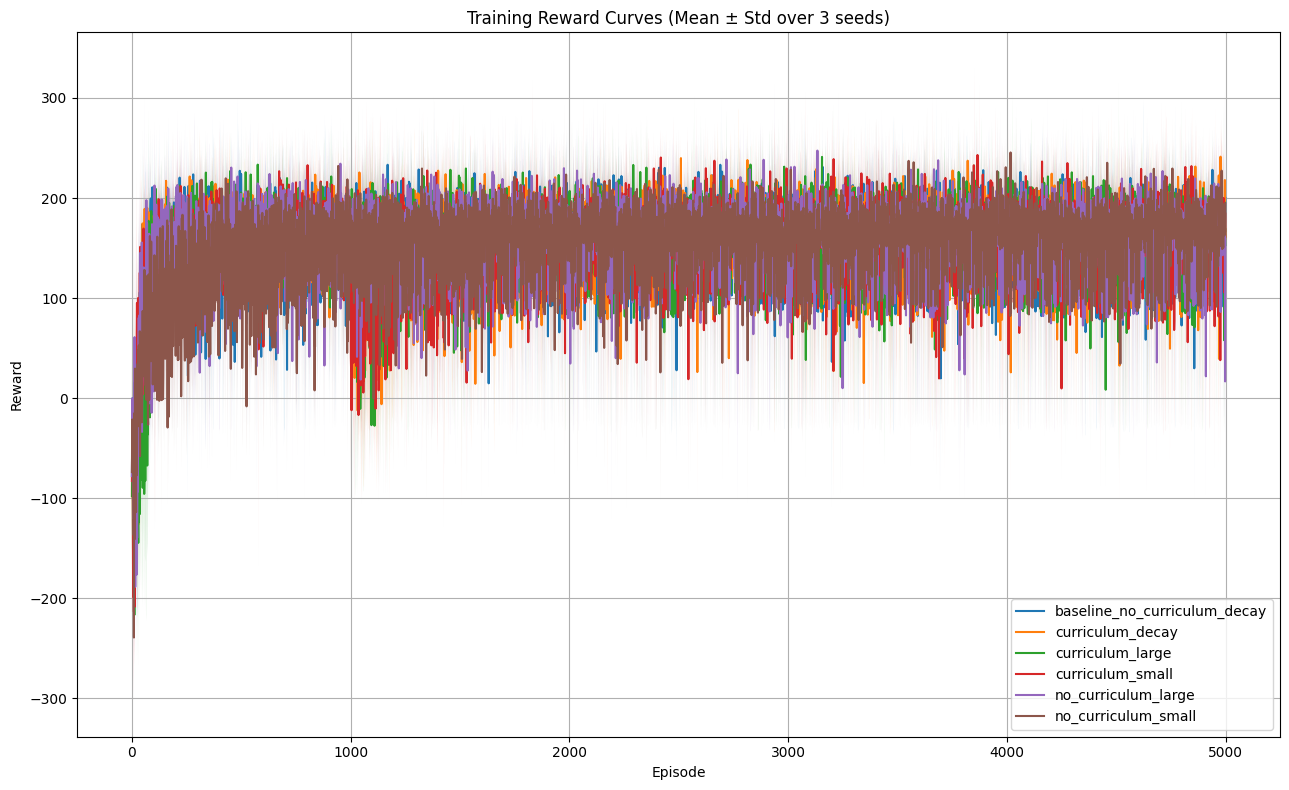

In [15]:
plt.figure(figsize=(13, 8))

for exp_name, group in train_df.groupby('experiment_name'):
    mean_curve = group.groupby('episode')['reward'].mean()
    std_curve = group.groupby('episode')['reward'].std().fillna(0)

    plt.plot(mean_curve.index, mean_curve.values, label=exp_name)
    plt.fill_between(
        mean_curve.index,
        mean_curve.values - std_curve.values,
        mean_curve.values + std_curve.values,
        alpha=0.15
    )

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Training Reward Curves (Mean ± Std over 3 seeds)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(root_dir, 'reward_curves_by_experiment.png'))
plt.show()

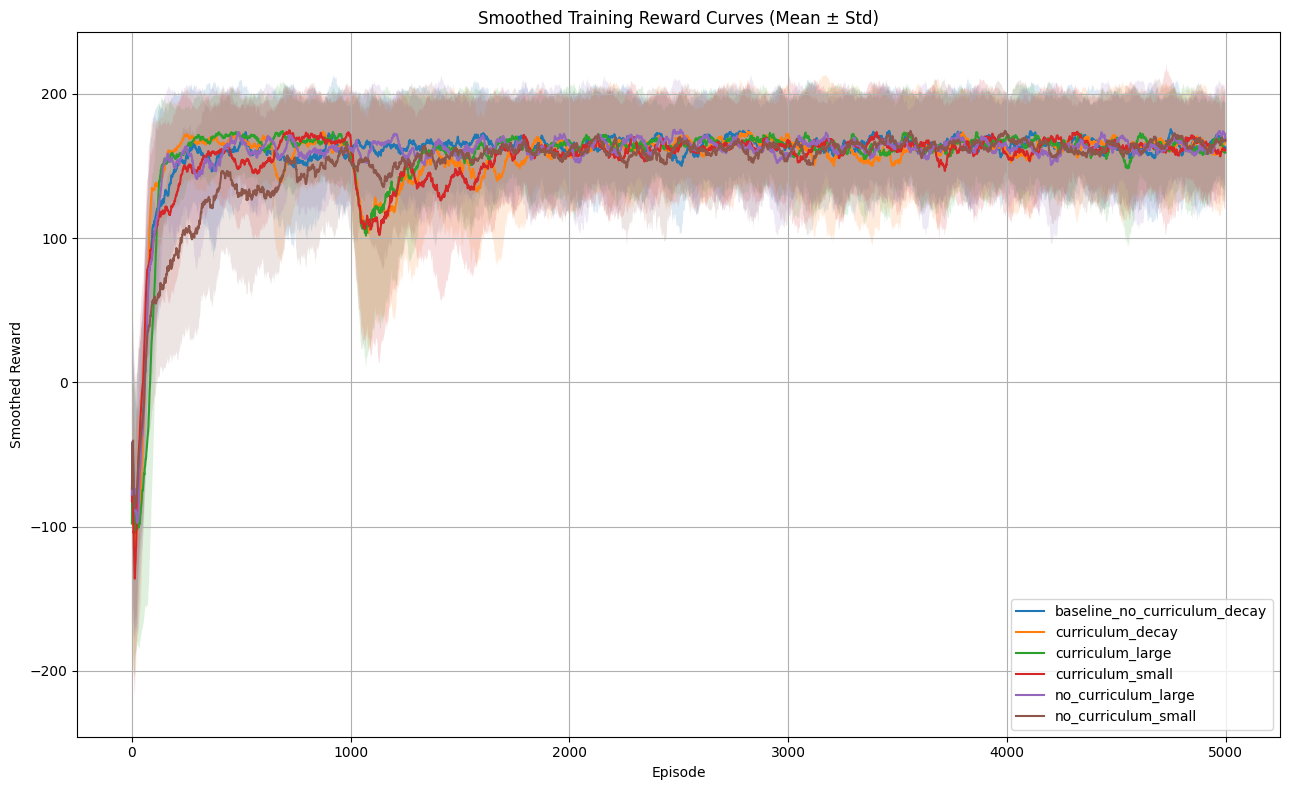

In [16]:
plt.figure(figsize=(13, 8))

for exp_name, group in train_df.groupby('experiment_name'):
    mean_curve = group.groupby('episode')['reward'].mean()
    std_curve = group.groupby('episode')['reward'].std().fillna(0)

    mean_smooth = mean_curve.rolling(window=50, min_periods=1).mean()
    std_smooth = std_curve.rolling(window=50, min_periods=1).mean()

    plt.plot(mean_smooth.index, mean_smooth.values, label=exp_name)
    plt.fill_between(
        mean_smooth.index,
        mean_smooth.values - std_smooth.values,
        mean_smooth.values + std_smooth.values,
        alpha=0.15
    )

plt.xlabel('Episode')
plt.ylabel('Smoothed Reward')
plt.title('Smoothed Training Reward Curves (Mean ± Std)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(root_dir, 'reward_curves_smoothed.png'))
plt.show()

In [17]:
summary_plot_df = results_df.groupby('experiment_name').agg({
    'test_success_rate': ['mean', 'std'],
    'test_collision_rate': ['mean', 'std'],
    'test_timeout_rate': ['mean', 'std'],
    'avg_final_distance': ['mean', 'std'],
    'avg_test_reward': ['mean', 'std']
}).reset_index()

summary_plot_df.columns = [
    'experiment_name',
    'success_mean', 'success_std',
    'collision_mean', 'collision_std',
    'timeout_mean', 'timeout_std',
    'distance_mean', 'distance_std',
    'reward_mean', 'reward_std'
]

summary_plot_df.to_csv(os.path.join(root_dir, 'metrics_summary_for_plot.csv'), index=False)
summary_plot_df

,experiment_name,success_mean,success_std,collision_mean,collision_std,timeout_mean,timeout_std,distance_mean,distance_std,reward_mean,reward_std
0,baseline_no_curriculum_decay,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.362416,0.028463,164.400580,6.497388
1,curriculum_decay,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.354973,0.042642,164.006502,4.535328
2,curriculum_large,0.933333,0.057735,0.0,0.0,0.066667,0.057735,1.549465,0.286163,159.485785,11.290335
3,curriculum_small,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.375392,0.013672,163.565653,6.876062
4,no_curriculum_large,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.373045,0.016909,163.461941,4.691968
5,no_curriculum_small,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.321493,0.016153,164.660051,7.611793


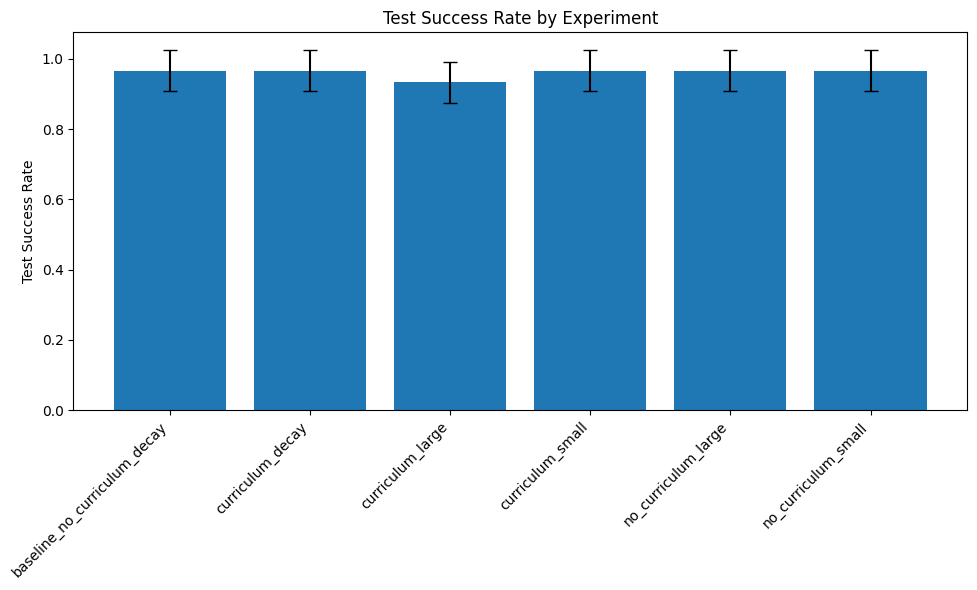

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(
    summary_plot_df['experiment_name'],
    summary_plot_df['success_mean'],
    yerr=summary_plot_df['success_std'],
    capsize=5
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Test Success Rate')
plt.title('Test Success Rate by Experiment')
plt.tight_layout()
plt.savefig(os.path.join(root_dir, 'test_success_rate.png'))
plt.show()

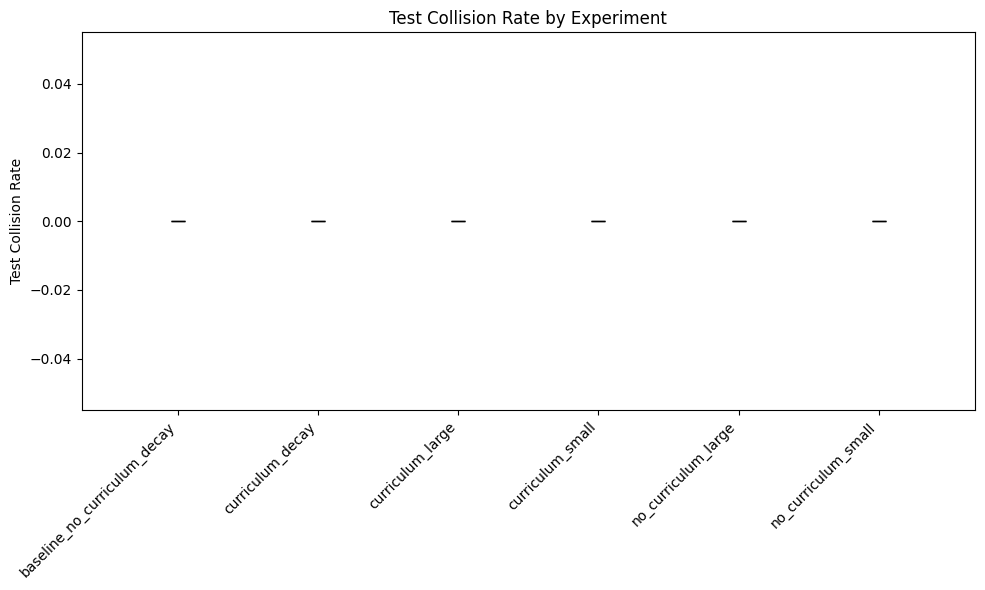

In [19]:
plt.figure(figsize=(10, 6))
plt.bar(
    summary_plot_df['experiment_name'],
    summary_plot_df['collision_mean'],
    yerr=summary_plot_df['collision_std'],
    capsize=5
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Test Collision Rate')
plt.title('Test Collision Rate by Experiment')
plt.tight_layout()
plt.savefig(os.path.join(root_dir, 'test_collision_rate.png'))
plt.show()

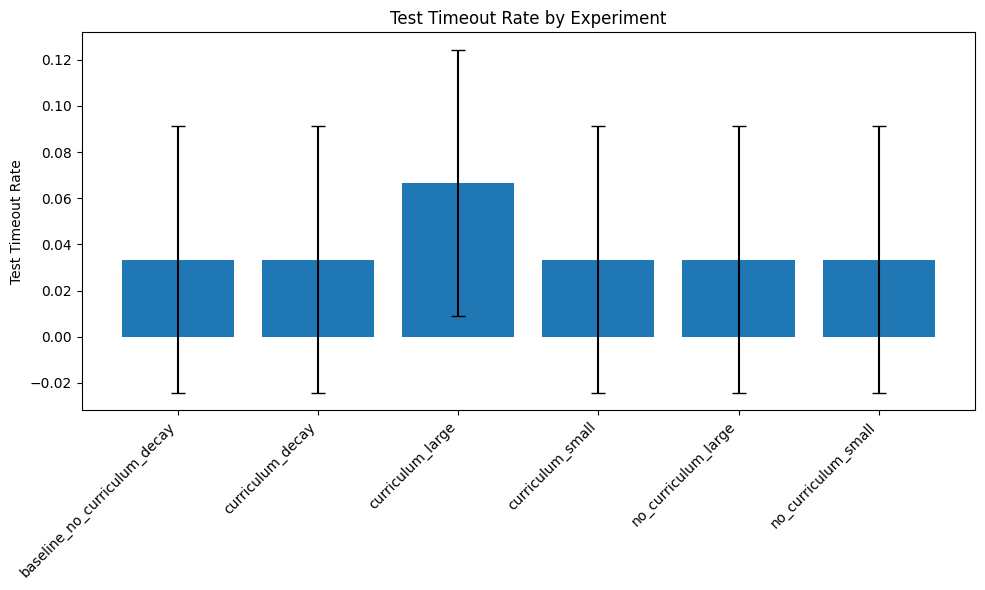

In [20]:
plt.figure(figsize=(10, 6))
plt.bar(
    summary_plot_df['experiment_name'],
    summary_plot_df['timeout_mean'],
    yerr=summary_plot_df['timeout_std'],
    capsize=5
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Test Timeout Rate')
plt.title('Test Timeout Rate by Experiment')
plt.tight_layout()
plt.savefig(os.path.join(root_dir, 'test_timeout_rate.png'))
plt.show()

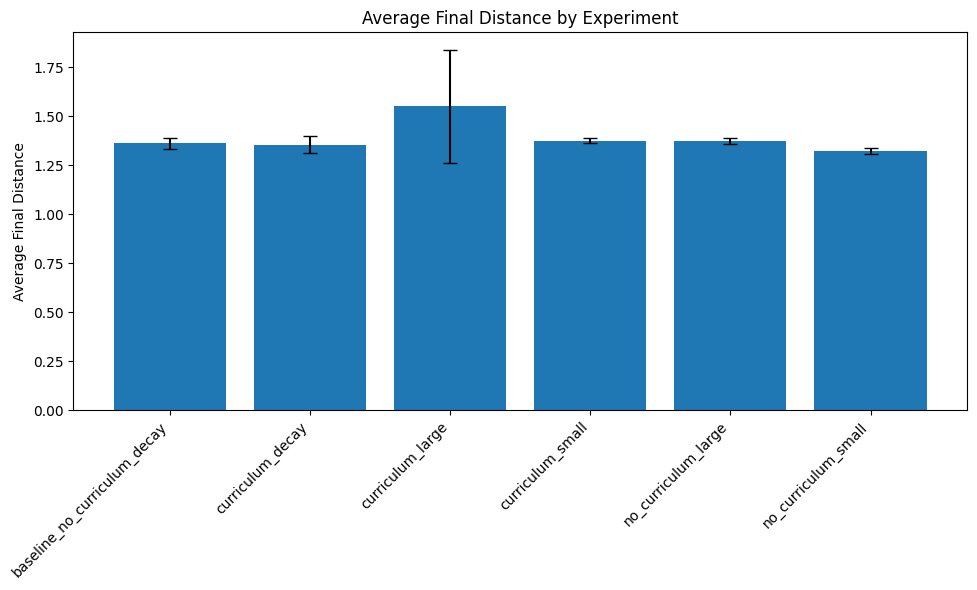

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(
    summary_plot_df['experiment_name'],
    summary_plot_df['distance_mean'],
    yerr=summary_plot_df['distance_std'],
    capsize=5
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Final Distance')
plt.title('Average Final Distance by Experiment')
plt.tight_layout()
plt.savefig(os.path.join(root_dir, 'avg_final_distance.png'))
plt.show()

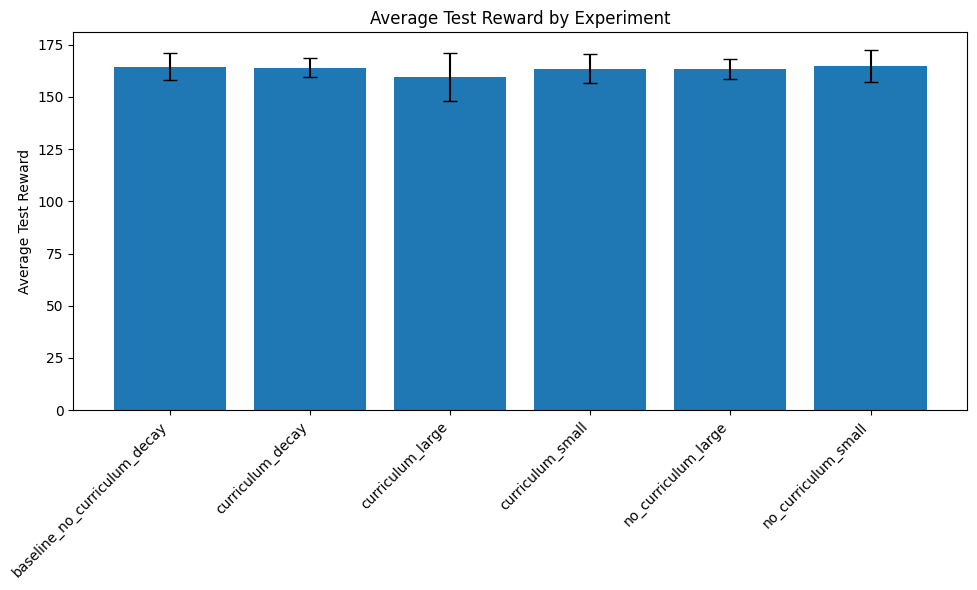

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(
    summary_plot_df['experiment_name'],
    summary_plot_df['reward_mean'],
    yerr=summary_plot_df['reward_std'],
    capsize=5
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Test Reward')
plt.title('Average Test Reward by Experiment')
plt.tight_layout()
plt.savefig(os.path.join(root_dir, 'avg_test_reward.png'))
plt.show()

In [23]:
final_table = results_df.groupby('experiment_name').agg({
    'test_success_rate': ['mean', 'std'],
    'test_collision_rate': ['mean', 'std'],
    'test_timeout_rate': ['mean', 'std'],
    'avg_final_distance': ['mean', 'std'],
    'avg_test_reward': ['mean', 'std']
}).round(4)

final_table.to_csv(os.path.join(root_dir, 'final_metrics_table.csv'))
final_table

test_success_rate         test_collision_rate  \
                                          mean     std                mean   
experiment_name                                                              
baseline_no_curriculum_decay            0.9667  0.0577                 0.0   
curriculum_decay                        0.9667  0.0577                 0.0   
curriculum_large                        0.9333  0.0577                 0.0   
curriculum_small                        0.9667  0.0577                 0.0   
no_curriculum_large                     0.9667  0.0577                 0.0   
no_curriculum_small                     0.9667  0.0577                 0.0   

                                  test_timeout_rate          \
                              std              mean     std   
experiment_name                                               
baseline_no_curriculum_decay  0.0            0.0333  0.0577   
curriculum_decay              0.0            0.0333  0.0577   
curriculum_large              0.0            0.0667  0.0577   
curriculum_small              0.0            0.0333  0.0577   
no_curriculum_large           0.0            0.0333  0.0577   
no_curriculum_small           0.0            0.0333  0.0577   

                             avg_final_distance         avg_test_reward  \
                                           mean     std            mean   
experiment_name                                                           
baseline_no_curriculum_decay             1.3624  0.0285        164.4006   
curriculum_decay                         1.3550  0.0426        164.0065   
curriculum_large                         1.5495  0.2862        159.4858   
curriculum_small                         1.3754  0.0137        163.5657   
no_curriculum_large                      1.3730  0.0169        163.4619   
no_curriculum_small                      1.3215  0.0162        164.6601   

                                       
                                  std  
experiment_name                        
baseline_no_curriculum_decay   6.4974  
curriculum_decay               4.5353  
curriculum_large              11.2903  
curriculum_small               6.8761  
no_curriculum_large            4.6920  
no_curriculum_small            7.6118

In [24]:
rank_df = summary_plot_df.copy()

rank_df = rank_df.sort_values(
    by=['success_mean', 'distance_mean', 'collision_mean'],
    ascending=[False, True, True]
).reset_index(drop=True)

rank_df

,experiment_name,success_mean,success_std,collision_mean,collision_std,timeout_mean,timeout_std,distance_mean,distance_std,reward_mean,reward_std
0,no_curriculum_small,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.321493,0.016153,164.660051,7.611793
1,curriculum_decay,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.354973,0.042642,164.006502,4.535328
2,baseline_no_curriculum_decay,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.362416,0.028463,164.400580,6.497388
3,no_curriculum_large,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.373045,0.016909,163.461941,4.691968
4,curriculum_small,0.966667,0.057735,0.0,0.0,0.033333,0.057735,1.375392,0.013672,163.565653,6.876062
5,curriculum_large,0.933333,0.057735,0.0,0.0,0.066667,0.057735,1.549465,0.286163,159.485785,11.290335


In [25]:
!zip -r ablation_results.zip ablation_results
print("已压缩为 ablation_results.zip")

/bin/bash: line 1: zip: command not found
已压缩为 ablation_results.zip
